In [1]:
import practicalSPARQL
import pandas as pd
import ast
import matplotlib.pyplot as plt
import numpy as np
import bqplot as bq
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import networkx as nx

In [2]:
df = pd.read_csv('full_image_data_feb_25.csv')
books = pd.read_csv('full_book_data_feb_25.csv')

In [3]:
# Assuming 'book_id' is the column to join on
df['printer'] = df['book'].map(books.set_index('book')['printers'])
df['publisher'] = df['book'].map(books.set_index('book')['publishers'])

In [4]:
# Define the target cks values
target_cks = [
   # 'CK_Structure of the Sublunar World',
   # 'CK_Qualities of the Aristotelian Elements',
   #  'CK_Symbols of the Elements',
   #  'CK_Relation Between the Spheres of Water and Earth'
]

In [5]:
#filtering the df to get the images of the target cks with all their data + printing counts
#(this is why only filter is not enough: we need all the cks that are in other rows with double images values)

# Step 1: Filter the DataFrame for rows where 'cks' is in the target_cks list
filtered_df_target_cks = df[df['cks'].isin(target_cks)]

# Step 2: Get the unique 'images' values associated with the target cks
images_with_target_cks = filtered_df_target_cks['images'].unique()

# Step 3: Filter the original DataFrame to include all rows that have these images
filtered_df = df[df['images'].isin(images_with_target_cks)]

# filtered_df

In [6]:
unique_counts = pd.concat([
    df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('df'),
    filtered_df[['images', 'cluster_name', 'cks', 'place', 'printer', 'publisher']].nunique().rename('filtered_df')
], axis=1)

print(unique_counts)

                 df  filtered_df
images        20540            0
cluster_name   3563            0
cks             168            0
place            42            0
printer         166            0
publisher       155            0


In [7]:
# export cluster numbers for visual tagging if needed

# # Extract unique values
# unique_clusters = filtered_df['cluster_name'].dropna().unique()

# # Save to CSV
# # pd.Series(unique_clusters).to_csv('/Users/nogashlomi/projects/Image_data/visual_tags/1.3.csv', index=False, header=False)

In [8]:
# #import the visual tagging: write the correcpt path to visual tagging table
# visual_tags = pd.read_csv('/Users/nogashlomi/projects/Image_data/visual_tags/1.3_sublunar_structure.csv')

In [9]:
# #compare cluster name values to check the visual tagging is done correctly

# # Get unique values
# visual_tags_clusters = set(visual_tags['cluster_name'].unique())
# filtered_df_clusters = set(filtered_df['cluster_name'].unique())

# # Compare
# only_in_visual_tags = visual_tags_clusters - filtered_df_clusters
# only_in_filtered_df = filtered_df_clusters - visual_tags_clusters
# in_both = visual_tags_clusters & filtered_df_clusters

# # Print results
# print("Unique cluster names only in visual_tags:")
# print(sorted(only_in_visual_tags))

# print("\nUnique cluster names only in filtered_df:")
# print(sorted(only_in_filtered_df))

# # print("\nCluster names present in both:")
# # print(sorted(in_both))


Number of Unique Books per Content Group (CKs) over Time:
   Books
0     14
1     37
2     30
3     48
4     88
5     69
6     45
7     23
8      4


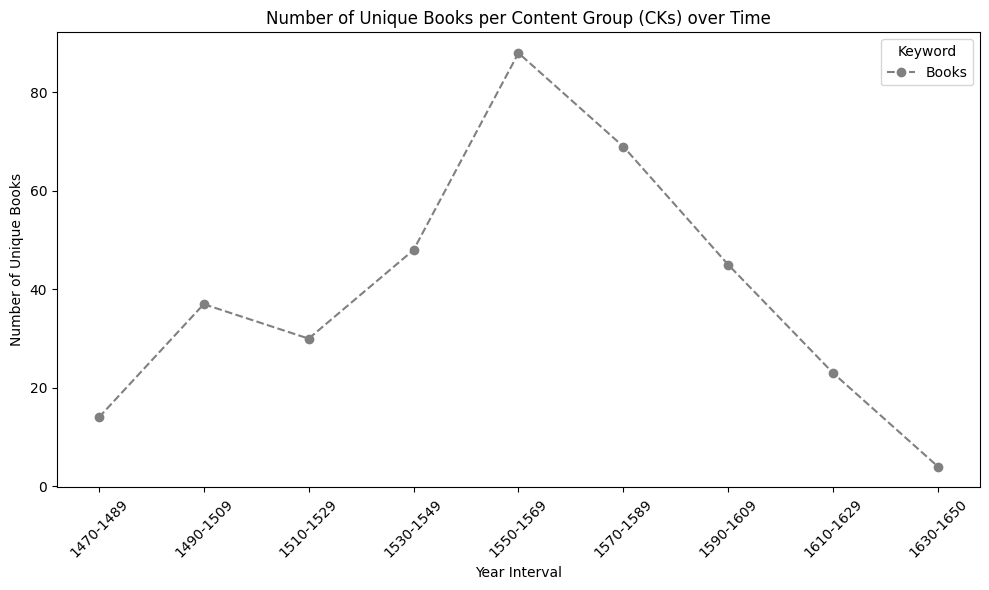

In [10]:
#plot number of books with images with relevant cks tags that were defined at the top.
#dont forget to update the file name in the save file line

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# Dictionary: {keyword: {interval: unique_book_count}}
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Create a DataFrame for the results
book_counts_df = pd.DataFrame(book_counts).fillna(0)

# Add the total number of books to the DataFrame
book_counts_df['Books'] = unique_books_count.values

# Print the results as a table (zero values will be included)
print("Number of Unique Books per Content Group (CKs) over Time:")
print(book_counts_df)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books (always included)
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (number of unique books per target_cks value)
for keyword, data in book_counts.items():
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]

    # Exclude zero values from plotting
    non_zero_values = [val for val in keyword_values if val > 0]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]

    if non_zero_values:  # Plot only if there are non-zero values
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Number of Unique Books per Content Group (CKs) over Time')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save plot if needed
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/xxx.png', dpi=300)

# Show the plot
plt.show()


=== Unique Image Counts per CK per Interval ===
               CK_Structure of the Sublunar World  \
year_interval                                       
1470-1489                                       5   
1490-1509                                      24   
1510-1529                                      13   
1530-1549                                       9   
1550-1569                                       7   
1570-1589                                      17   
1590-1609                                      17   
1610-1629                                       3   
1630-1650                                       1   

               CK_Qualities of the Aristotelian Elements  \
year_interval                                              
1470-1489                                              0   
1490-1509                                              0   
1510-1529                                              2   
1530-1549                                              3   
1550-15

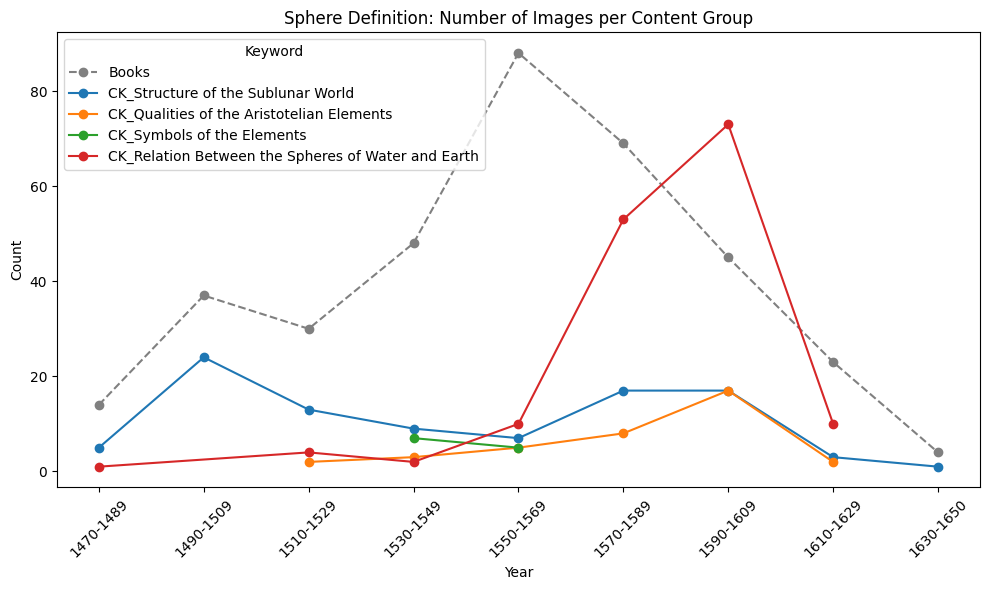

In [42]:
#plot number of images over time from the target cks - dont foget ot udpate save file line

# Get unique books per year_interval
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Define the master timeline from book data
intervals = unique_books_count.index.astype(str)

# Dictionary: {keyword: {interval: unique_image_count}}
counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Create a DataFrame for tabular display (fills in 0 for missing intervals)
counts_table = pd.DataFrame(counts, index=unique_books_count.index).fillna(0).astype(int)
print("\n=== Unique Image Counts per CK per Interval ===")
print(counts_table)

# Start plotting
plt.figure(figsize=(10, 6))

# Plot books
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each keyword (excluding zero values from the line)
for keyword in target_cks:
    data = counts.get(keyword, {})
    keyword_values = [data.get(interval, 0) for interval in unique_books_count.index]
    non_zero_intervals = [intervals[i] for i, val in enumerate(keyword_values) if val > 0]
    non_zero_values = [val for val in keyword_values if val > 0]
    
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# Final touches
plt.title('Sphere Definition: Number of Images per Content Group')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Keyword')
plt.tight_layout()

# Save the plot
# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/xxx.png', dpi=300)
plt.show()


In [43]:
#merge visual tags with filtered_df on cluster_name
visual_df = pd.merge(filtered_df, visual_tags, on='cluster_name')
visual_df

,images,cluster_name,cks,book,bid,part_or_adaption,part_or_adaption_label,type_label,custom_identifier,place,...,longitude,printer,publisher,decoration,3D,table-like,decorative-info,diagram,oval shape,Column1
0,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_00438,CK_Structure of the Sublunar World,http://sphaera.mpiwg-berlin.mpg.de/id/item/0be...,1924,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Anonymous commentary (foeliciter inchoat),"Annotated, Content",322.0,Venice,...,12.334590,Company Johannes Lucilius Santritter & Girolam...,Company Johannes Lucilius Santritter & Girolam...,no,no,no,yes,no,no,NaN
1,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_00438,CK_Ecumene Conception,http://sphaera.mpiwg-berlin.mpg.de/id/item/0be...,1924,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Anonymous commentary (foeliciter inchoat),"Annotated, Content",322.0,Venice,...,12.334590,Company Johannes Lucilius Santritter & Girolam...,Company Johannes Lucilius Santritter & Girolam...,no,no,no,yes,no,no,NaN
2,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_00671,CK_Relation Between the Spheres of Water and E...,http://sphaera.mpiwg-berlin.mpg.de/id/item/1ae...,1938,http://sphaera.mpiwg-berlin.mpg.de/id/part/c61...,Tractatus de sphaera,"Original Part, Content",100.0,Ferrara,...,11.618645,"Belfortis, Andreas","Belfortis, Andreas",no,no,no,no,no,no,NaN
3,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_00671,CK_Earth and Cosmos,http://sphaera.mpiwg-berlin.mpg.de/id/item/1ae...,1938,http://sphaera.mpiwg-berlin.mpg.de/id/part/c61...,Tractatus de sphaera,"Original Part, Content",100.0,Ferrara,...,11.618645,"Belfortis, Andreas","Belfortis, Andreas",no,no,no,no,no,no,NaN
4,http://db.sphaera.mpiwg-berlin.mpg.de/containe...,SAC_SIL_00670,CK_Structure of the Sublunar World,http://sphaera.mpiwg-berlin.mpg.de/id/item/016...,2201,http://sphaera.mpiwg-berlin.mpg.de/id/part/c61...,Tractatus de sphaera,"Original Part, Content",100.0,Leipzig,...,12.374733,"Kachelofen, Konrad","Kachelofen, Konrad",no,no,no,no,no,no,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
451,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_01862,CK_Structure of the Sublunar World,http://sphaera.mpiwg-berlin.mpg.de/id/item/b96...,1822,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Clavius's commentary on Sacrobosco's Sphere,"Content, Annotated",295.0,Lyon,...,4.832011,"Polère, Amédée","Rigaud, Pierre",yes,yes,no,yes,no,yes,NaN
452,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_01862,CK_Terraqueous Globe,http://sphaera.mpiwg-berlin.mpg.de/id/item/b96...,1822,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Clavius's commentary on Sacrobosco's Sphere,"Content, Annotated",295.0,Lyon,...,4.832011,"Polère, Amédée","Rigaud, Pierre",yes,yes,no,yes,no,yes,NaN
453,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_01069,CK_Relation Between the Spheres of Water and E...,http://sphaera.mpiwg-berlin.mpg.de/id/item/b96...,1822,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Clavius's commentary on Sacrobosco's Sphere,"Content, Annotated",295.0,Lyon,...,4.832011,"Polère, Amédée","Rigaud, Pierre",no,no,no,no,yes,no,NaN
454,http://dev.sphaera.mpiwg-berlin.mpg.de/contain...,SAC_SIL_01944,CK_Relation Between the Spheres of Water and E...,http://sphaera.mpiwg-berlin.mpg.de/id/item/b96...,1822,http://sphaera.mpiwg-berlin.mpg.de/id/adaption...,Clavius's commentary on Sacrobosco's Sphere,"Content, Annotated",295.0,Lyon,...,4.832011,"Polère, Amédée","Rigaud, Pierre",yes,yes,no,yes,no,no,NaN


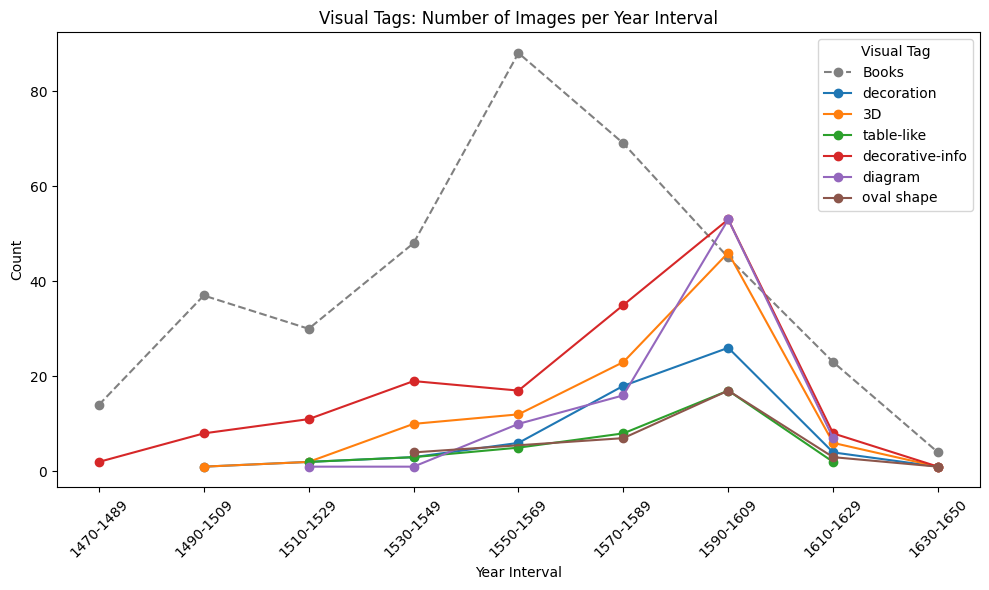

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Replace with the actual visual tag column names
defined_columns = ['decoration', '3D', 'table-like', 'decorative-info', 'diagram', 'oval shape']

# Plot number of books per interval
plt.plot(intervals, unique_books_count.values, label='Books', marker='o', color='grey', linestyle='--')

# Plot each visual tag
for col in defined_columns:
    yes_per_interval = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['images']
        .nunique()
        .reindex(unique_books_count.index, fill_value=0)
    )

    # Filter out zero values before plotting
    non_zero_intervals = [interval for interval, val in zip(intervals, yes_per_interval.values) if val > 0]
    non_zero_values = [val for val in yes_per_interval.values if val > 0]

    if non_zero_values:  # Plot only if there are values to show
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=col)

# Final touches
plt.title('Visual Tags: Number of Images per Year Interval')
plt.xlabel('Year Interval')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Visual Tag')
plt.tight_layout()

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_visual.png', dpi=300)
plt.show()


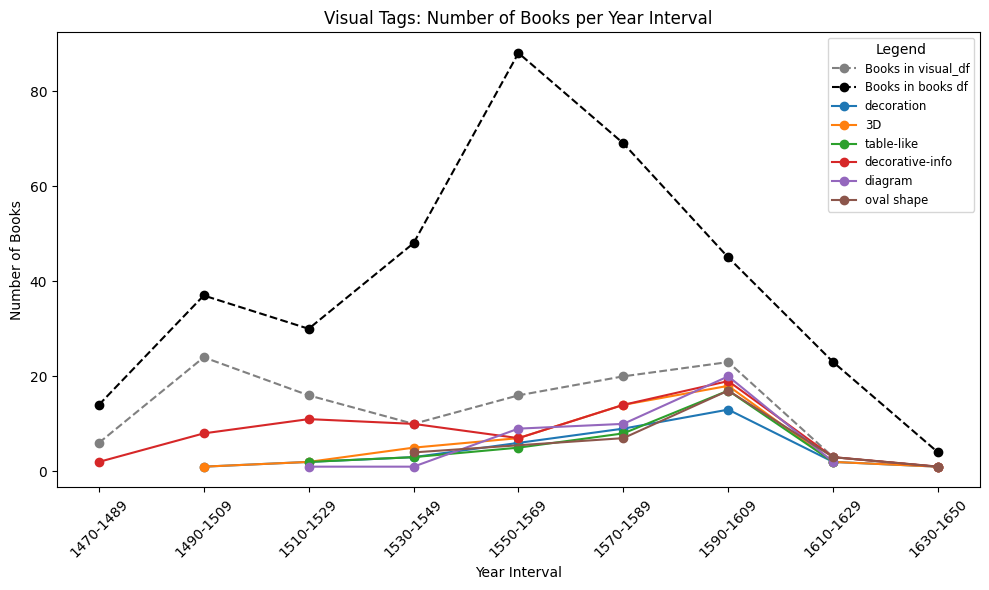

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Define visual tag columns
defined_columns = ['decoration', '3D', 'table-like', 'decorative-info', 'diagram', 'oval shape']

# Define sorted intervals
intervals = sorted(visual_df['year_interval'].dropna().unique())

# 1. Total unique books per interval in visual_df
unique_books_visual = (
    visual_df.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# 2. Total unique books per interval in books df
unique_books_from_books_df = (
    books.groupby('year_interval', observed=False)['book']
    .nunique()
    .reindex(intervals, fill_value=0)
)

# Plot total lines
plt.plot(intervals, unique_books_visual.values, label='Books in visual_df', marker='o', color='grey', linestyle='--')
plt.plot(intervals, unique_books_from_books_df.values, label='Books in books df', marker='o', color='black', linestyle='--')

# 3. Plot each visual tag with zero-excluding logic
for col in defined_columns:
    books_with_tag = (
        visual_df[visual_df[col] == 'yes']
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(intervals, fill_value=0)
    )

    # Filter out intervals with zero values
    non_zero_intervals = [interval for interval, val in zip(intervals, books_with_tag.values) if val > 0]
    non_zero_values = [val for val in books_with_tag.values if val > 0]

    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=col)

# Final formatting
plt.title('Visual Tags: Number of Books per Year Interval')
plt.xlabel('Year Interval')
plt.ylabel('Number of Books')
plt.xticks(rotation=45)
plt.legend(title='Legend', fontsize='small', title_fontsize='medium')
plt.tight_layout()

# Save and show
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_visual_books.png', dpi=300)
plt.show()


In [46]:
#network analysis: by place
#first step: create a df with two types of nodes: content and visal tags and places.
#the df lists each combination of place and tag/keyword

# Step 1: Define places and tags
places = visual_df['place'].unique().tolist()

# Visual tag columns (boolean yes/no)
visual_tag_cols = ['decoration', '3D', 'table-like', 'decorative-info', 'diagram', 'oval shape']

# All unique cks values (drop empty or NaN)
cks_tags = visual_df['cks'].dropna().unique().tolist()

# Combine all tags into one list (tags will be the second type of node)
all_tags = cks_tags + visual_tag_cols

# Step 2: Build the edge list
edges = []

# For each place
for place in places:
    place_data = visual_df[visual_df['place'] == place]

    # Check for each cks tag
    for cks in cks_tags:
        if (place_data['cks'] == cks).any():
            edges.append((place, cks))

    # Check for each visual tag
    for tag in visual_tag_cols:
        if (place_data[tag] == 'yes').any():
            edges.append((place, tag))

# Step 3: Create edge DataFrame (optional, for visualization or checking)
edges_df = pd.DataFrame(edges, columns=['place', 'tag'])

# Show the final edge list
print(edges_df)

      place                                                tag
0    Venice                 CK_Structure of the Sublunar World
1    Venice                              CK_Ecumene Conception
2    Venice  CK_Relation Between the Spheres of Water and E...
3    Venice          CK_Qualities of the Aristotelian Elements
4    Venice                               CK_Terraqueous Globe
..      ...                                                ...
178  Madrid                                                 3D
179  Madrid                                         table-like
180  Madrid                                    decorative-info
181  London  CK_Relation Between the Spheres of Water and E...
182  London                                            diagram

[183 rows x 2 columns]


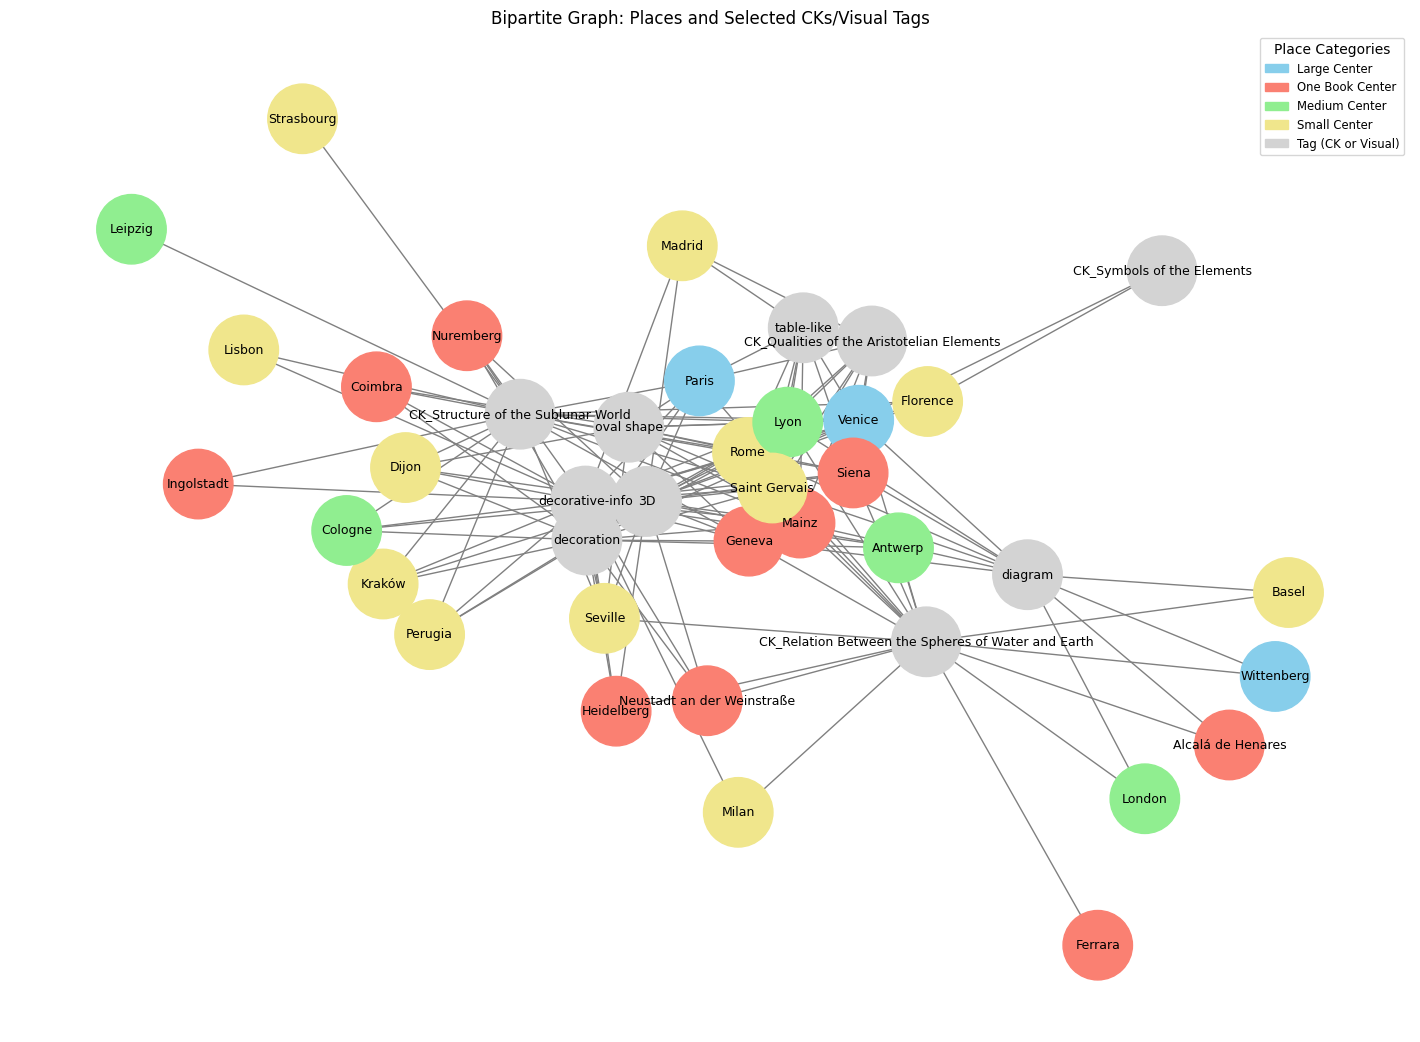

In [47]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.patches as mpatches

# Step 1: Define your filters
# target_cks = ['function', 'craft', 'symbolism', 'geometry']  # your selected CKs
visual_tags = ['3D', 'diagram', 'oval shape', 'decorative-info', 'decoration', 'table-like']  # columns with yes/no values

# Step 2: Initialize edge list
edges = []

# Add edges for target CKs
filtered_cks_df = visual_df[visual_df['cks'].isin(target_cks)]
edges.extend(list(zip(filtered_cks_df['place'], filtered_cks_df['cks'])))

# Add edges for visual tag columns (only where value is 'yes')
for tag in visual_tags:
    tag_df = visual_df[visual_df[tag] == 'yes']
    edges.extend(list(zip(tag_df['place'], [tag]*len(tag_df))))

# Step 3: Create node sets
places = list(set([edge[0] for edge in edges]))
tags = list(set([edge[1] for edge in edges]))

# Step 4: Get place categories and assign colors
unique_categories = visual_df['place_category'].dropna().unique()
category_color_map = {cat: color for cat, color in zip(unique_categories, ['skyblue', 'salmon', 'lightgreen', 'khaki'])}

# Map place to its category color
place_color_map = {}
for place in places:
    category_series = visual_df[visual_df['place'] == place]['place_category']
    category = category_series.dropna().iloc[0] if not category_series.dropna().empty else None
    place_color_map[place] = category_color_map.get(category, 'gray')

# Step 5: Build the graph
G = nx.Graph()
G.add_nodes_from(places, bipartite=0)
G.add_nodes_from(tags, bipartite=1)
G.add_edges_from(edges)

# Step 6: Assign node colors
node_colors = []
for node in G.nodes():
    if node in places:
        node_colors.append(place_color_map.get(node, 'gray'))
    else:
        node_colors.append('lightgray')  # tags (CKs or visual)

# Step 7: Draw the graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color='gray', node_size=2500, font_size=9)

# Step 8: Create legend
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (CK or Visual)'))

plt.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.title("Bipartite Graph: Places and Selected CKs/Visual Tags")
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_place_network.png', dpi=300)
plt.show()


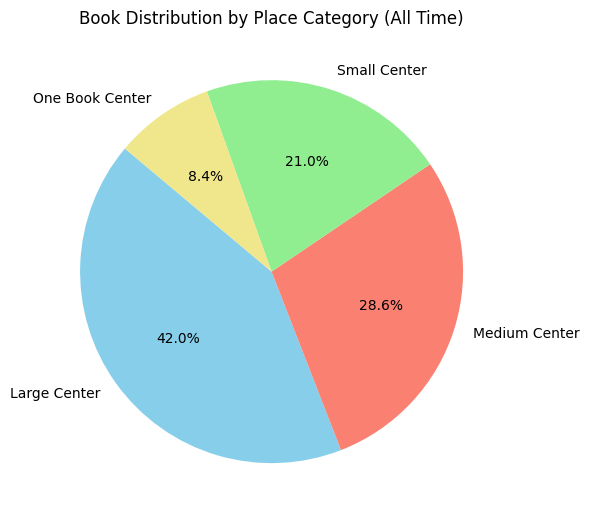

In [68]:
import matplotlib.pyplot as plt

# Drop duplicate books to count each only once
unique_books = visual_df.drop_duplicates(subset='book')

# Count number of books per place_category
book_counts_all = (
    unique_books
    .groupby('place_category')['book']
    .count()
    .sort_values(ascending=False)
)

# Define consistent color mapping
unique_categories = book_counts_all.index.tolist()
category_color_map = {
    cat: color for cat, color in zip(
        unique_categories,
        ['skyblue', 'salmon', 'lightgreen', 'khaki', 'plum', 'orange', 'lightcoral', 'lightsteelblue']
    )
}

# Plot pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    book_counts_all,
    labels=book_counts_all.index,
    autopct='%1.1f%%',
    colors=[category_color_map.get(cat, 'gray') for cat in book_counts_all.index],
    startangle=140
)
plt.title('Book Distribution by Place Category (All Time)')
plt.tight_layout()

# Optional: Save the figure
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_place_category_pie.png', dpi=300)

plt.show()


In [48]:
# Step 1: Define printers and tags
printers = visual_df['printer'].dropna().unique().tolist()

# Visual tag columns (boolean yes/no)
visual_tag_cols = ['decoration', '3D', 'table-like', 'decorative-info', 'diagram', 'oval shape']

# Define your selected CKs (not all CKs in the data)
# target_cks = ['function', 'craft', 'symbolism', 'geometry']  # adjust as needed

# Combine all tags into one list (for reference)
all_tags = target_cks + visual_tag_cols

# Step 2: Build the edge list
edges = []

for printer in printers:
    printer_data = visual_df[visual_df['printer'] == printer]

    # Add edges for selected CKs
    for cks in target_cks:
        if (printer_data['cks'] == cks).any():
            edges.append((printer, cks))

    # Add edges for visual tags (if "yes")
    for tag in visual_tag_cols:
        if (printer_data[tag] == 'yes').any():
            edges.append((printer, tag))

# Step 3: Create DataFrame of edges (optional)
edges_df = pd.DataFrame(edges, columns=['printer', 'tag'])

# Preview the result
print(edges_df)


                                               printer  \
0    Company Johannes Lucilius Santritter & Girolam...   
1    Company Johannes Lucilius Santritter & Girolam...   
2                                   Belfortis, Andreas   
3                                   Kachelofen, Konrad   
4                                    Stöckel, Wolfgang   
..                                                 ...   
278                                     Polère, Amédée   
279                                     Polère, Amédée   
280                                     Polère, Amédée   
281                                     Judson, Thomas   
282                                     Judson, Thomas   

                                                   tag  
0                   CK_Structure of the Sublunar World  
1                                      decorative-info  
2    CK_Relation Between the Spheres of Water and E...  
3                   CK_Structure of the Sublunar World  
4                 

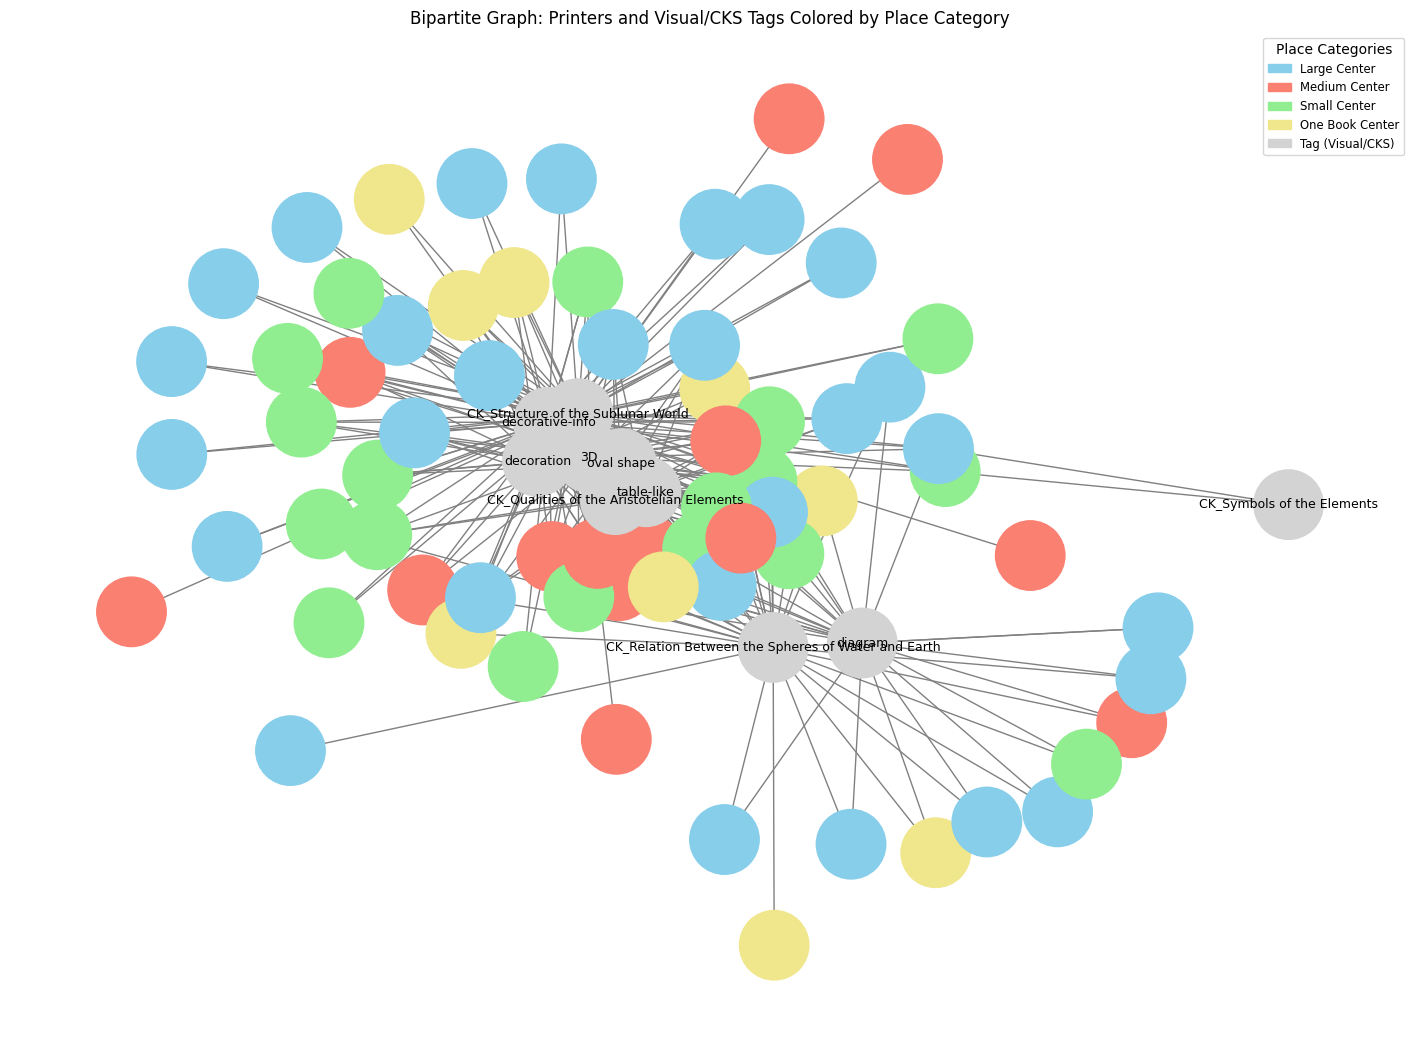

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# Define your selected CKs and visual tags
# target_cks = ['function', 'craft', 'symbolism', 'geometry']
visual_tags = ['3D', 'diagram', 'oval shape', 'decorative-info', 'decoration', 'table-like']

# Step 1: Build edge list
edges = []

# CKs edges
filtered_cks_df = visual_df[visual_df['cks'].isin(target_cks)]
edges.extend(list(zip(filtered_cks_df['printer'], filtered_cks_df['cks'])))

# Visual tag edges
for tag in visual_tags:
    tag_df = visual_df[visual_df[tag] == 'yes']
    edges.extend(list(zip(tag_df['printer'], [tag]*len(tag_df))))

# Step 2: Extract node sets
printers = list(set([edge[0] for edge in edges]))
all_tags = list(set([edge[1] for edge in edges]))

# Define ordered categories and colors
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

# Step 3: Assign colors to printers based on place_category
printer_color_map = {}
for printer in printers:
    category_series = visual_df[visual_df['printer'] == printer]['place_category']
    category = category_series.dropna().iloc[0] if not category_series.dropna().empty else None
    printer_color_map[printer] = category_color_map.get(category, 'gray')

# Step 4: Build graph
G = nx.Graph()
G.add_nodes_from(printers, bipartite=0)
G.add_nodes_from(all_tags, bipartite=1)
G.add_edges_from(edges)

# Step 5: Node colors
node_colors = []
for node in G.nodes():
    if node in printers:
        node_colors.append(printer_color_map.get(node, 'gray'))
    else:
        node_colors.append('lightgray')

# Step 6: Labels only for tags
labels = {node: node for node in G.nodes() if node in all_tags}

# Step 7: Draw the graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)
nx.draw(
    G, pos,
    labels=labels,
    node_color=node_colors,
    edge_color='gray',
    node_size=2500,
    font_size=9
)

# Step 8: Legend
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='lightgray', label='Tag (Visual/CKS)'))

plt.legend(handles=legend_handles, title='Place Categories', loc='upper right', fontsize='small', title_fontsize='medium')
plt.title("Bipartite Graph: Printers and Visual/CKS Tags Colored by Place Category")

# Export
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_printer_network.png', dpi=300, facecolor='white')
plt.show()


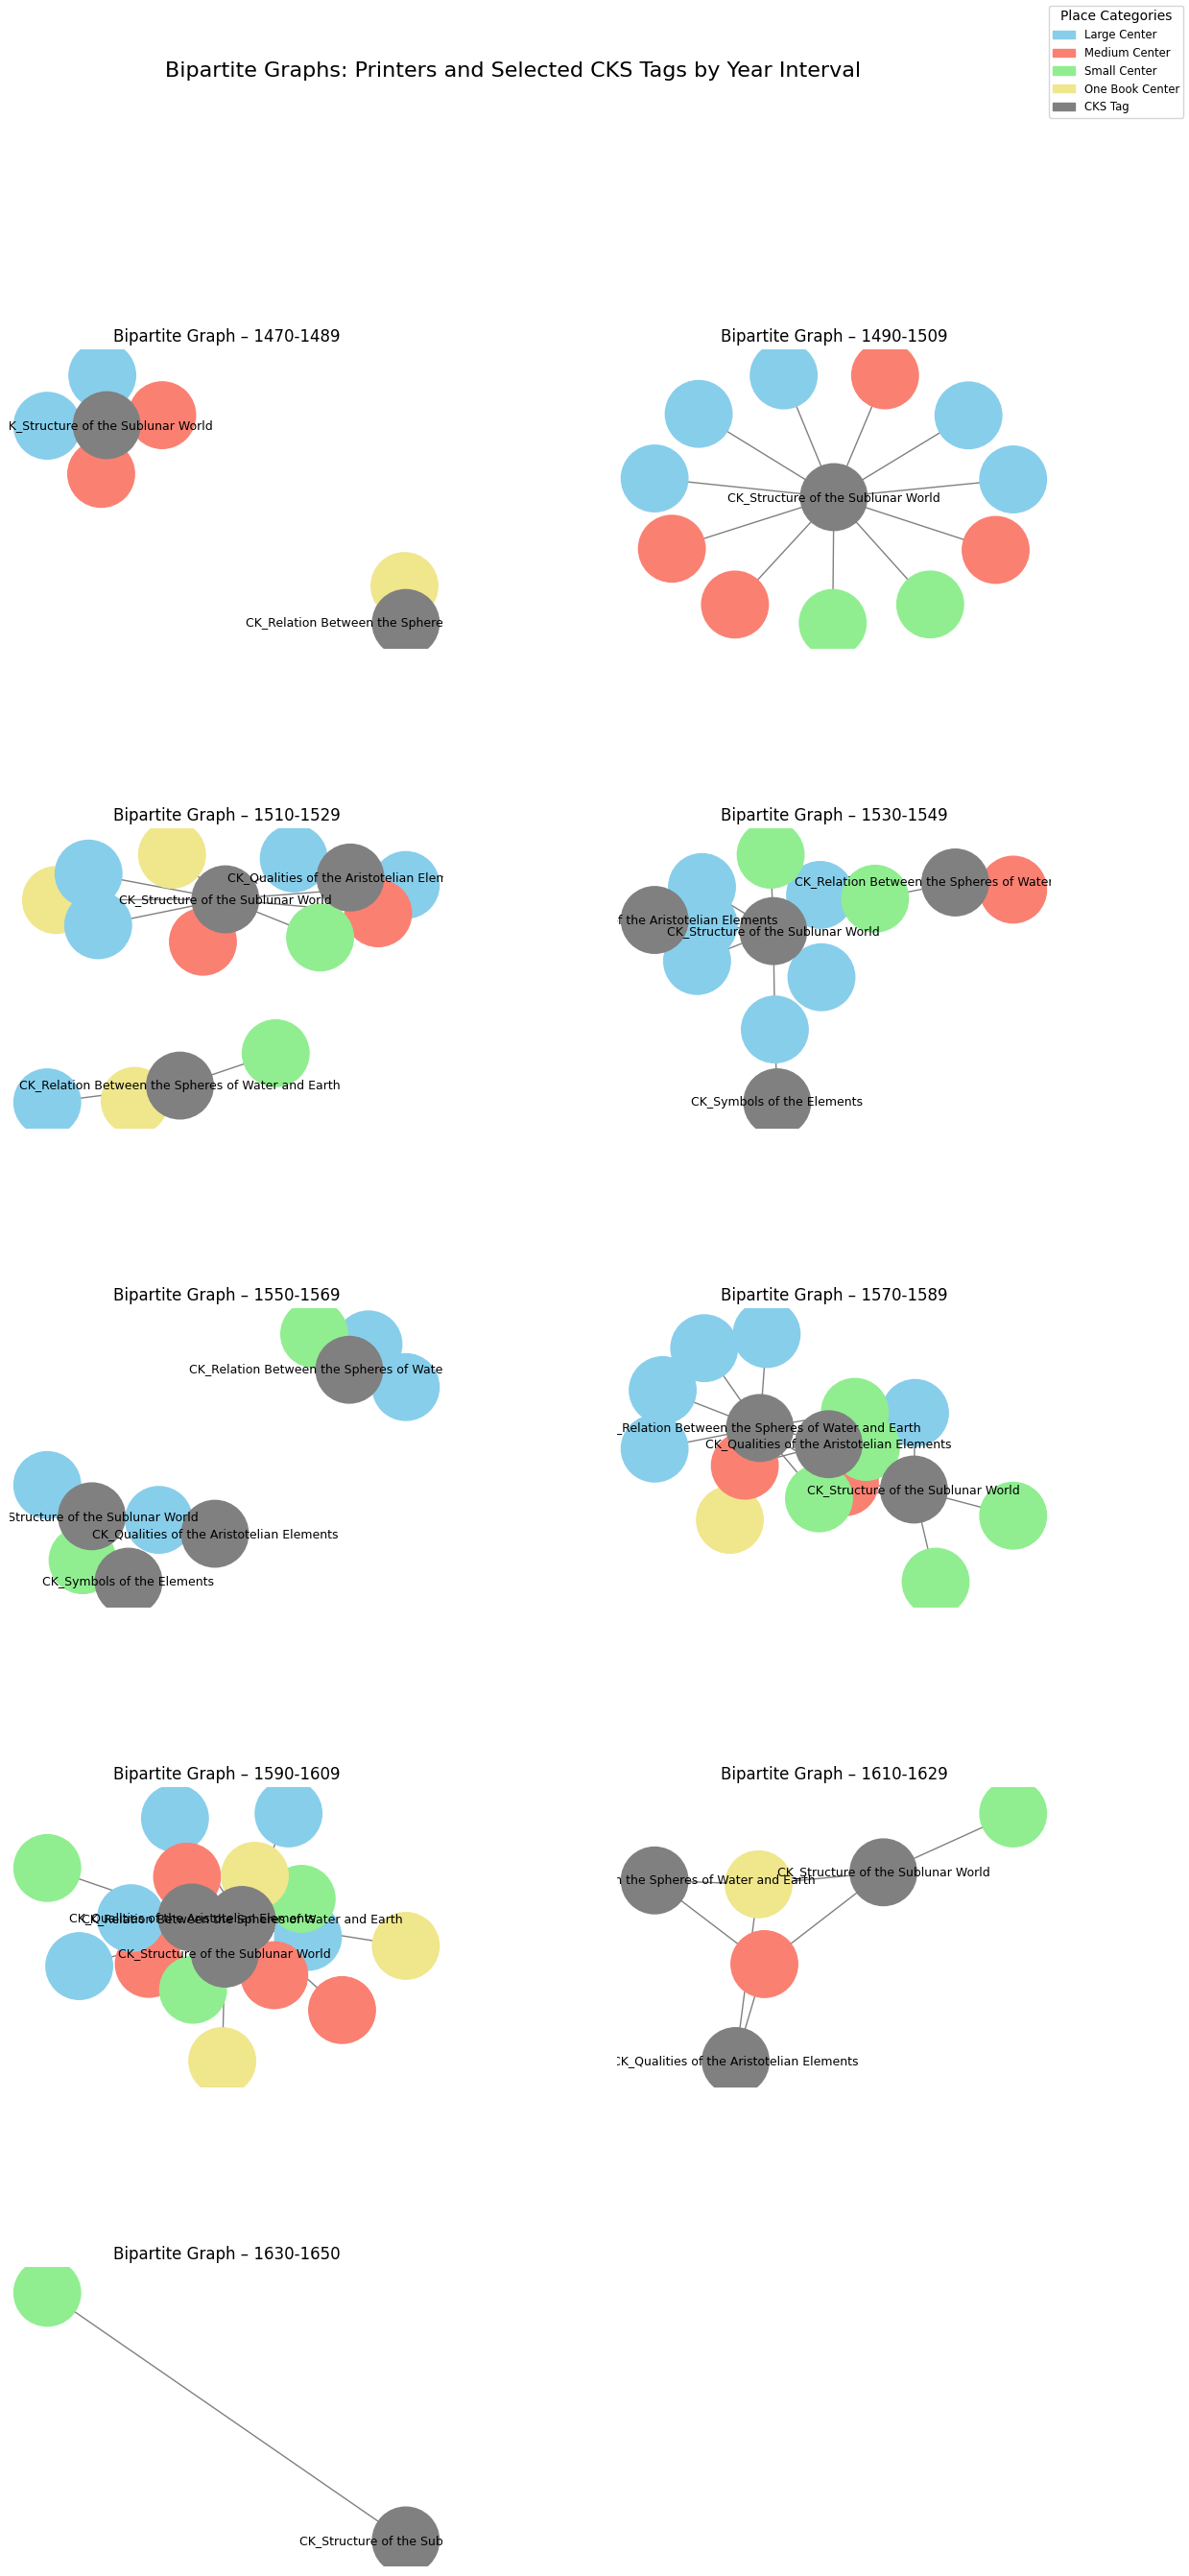

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

# === PARAMETERS ===
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
category_color_map = {
    'Large Center': 'skyblue',
    'Medium Center': 'salmon',
    'Small Center': 'lightgreen',
    'One Book Center': 'khaki'
}

keywords = [
   'CK_Structure of the Sublunar World',
   'CK_Qualities of the Aristotelian Elements',
   'CK_Symbols of the Elements',
   'CK_Relation Between the Spheres of Water and Earth'
]

# === FILTER TO JUST SELECTED CKS ===
subset_df = filtered_df[filtered_df['cks'].isin(keywords)].copy()

# === GET UNIQUE TIME INTERVALS ===
intervals = sorted(subset_df['year_interval'].dropna().unique())

# === CREATE SUBPLOTS ===
n_cols = 2
n_rows = (len(intervals) + 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 6 * n_rows))
plt.subplots_adjust(wspace=0.4, hspace=0.6)  # ⬅️ More space between plots
axes = axes.flatten()

# === LOOP OVER EACH TIME INTERVAL ===
for i, interval in enumerate(intervals):
    ax = axes[i]
    df_interval = subset_df[subset_df['year_interval'] == interval].copy()

    places = df_interval['printer'].dropna().unique().tolist()
    cks_tags = df_interval['cks'].dropna().unique().tolist()

    # Build edges
    edges = []
    for place in places:
        place_data = df_interval[df_interval['printer'] == place]
        for cks in cks_tags:
            if (place_data['cks'] == cks).any():
                edges.append((place, cks))
    edges_df = pd.DataFrame(edges, columns=['printer', 'cks']).drop_duplicates()

    # Place color mapping
    place_color_map = {
        place: category_color_map.get(
            filtered_df[filtered_df['printer'] == place]['place_category'].iloc[0],
            'gray'
        )
        for place in places
    }

    # Build graph
    G = nx.Graph()
    G.add_nodes_from(places, bipartite=0)
    G.add_nodes_from(cks_tags, bipartite=1)
    G.add_edges_from(edges_df.itertuples(index=False, name=None))

    # Node colors
    node_colors = [
        place_color_map.get(node, 'gray') if node in places else 'gray'
        for node in G.nodes()
    ]

    # Label only CKS nodes
    labels = {node: node for node in cks_tags}

    pos = nx.spring_layout(G, seed=42, k=0.5)

    # Draw graph
    nx.draw(
        G, pos,
        labels=labels,
        node_color=node_colors,
        edge_color='gray',
        node_size=2500,
        font_size=9,
        ax=ax
    )

    ax.set_title(f"Bipartite Graph – {interval}", fontsize=12)
    ax.axis('off')

# === REMOVE EMPTY AXES IF NEEDED ===
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# === LEGEND ===
legend_handles = [mpatches.Patch(color=category_color_map[cat], label=cat) for cat in ordered_categories]
legend_handles.append(mpatches.Patch(color='gray', label='CKS Tag'))

fig.legend(
    handles=legend_handles,
    title='Place Categories',
    loc='upper right',
    fontsize='small',
    title_fontsize='medium'
)

plt.suptitle("Bipartite Graphs: Printers and Selected CKS Tags by Year Interval", fontsize=16)
plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_printers_by_interval.png', dpi=300)
plt.show()


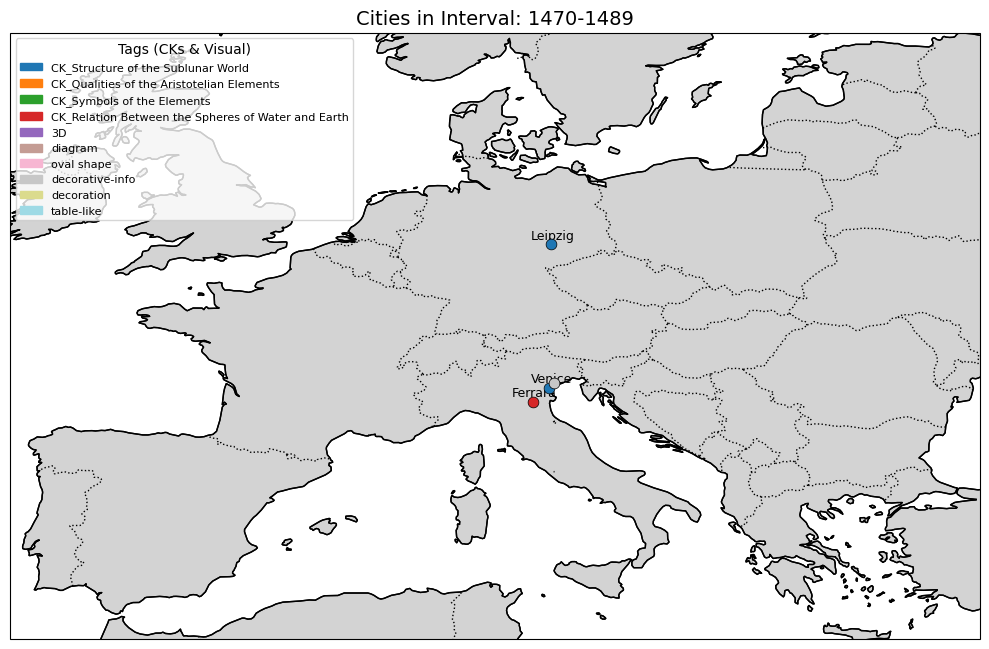

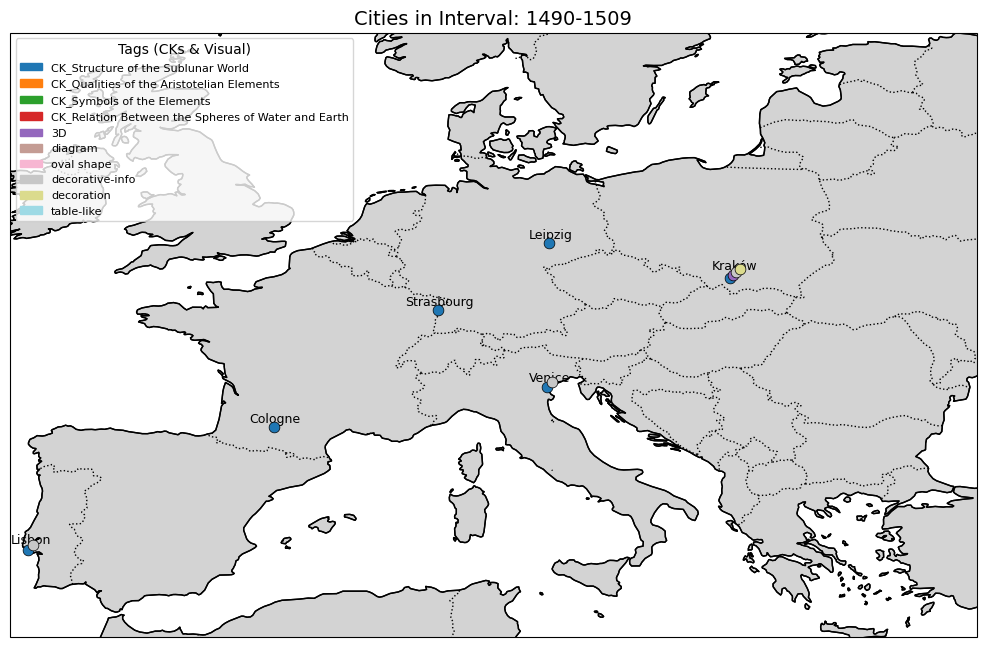

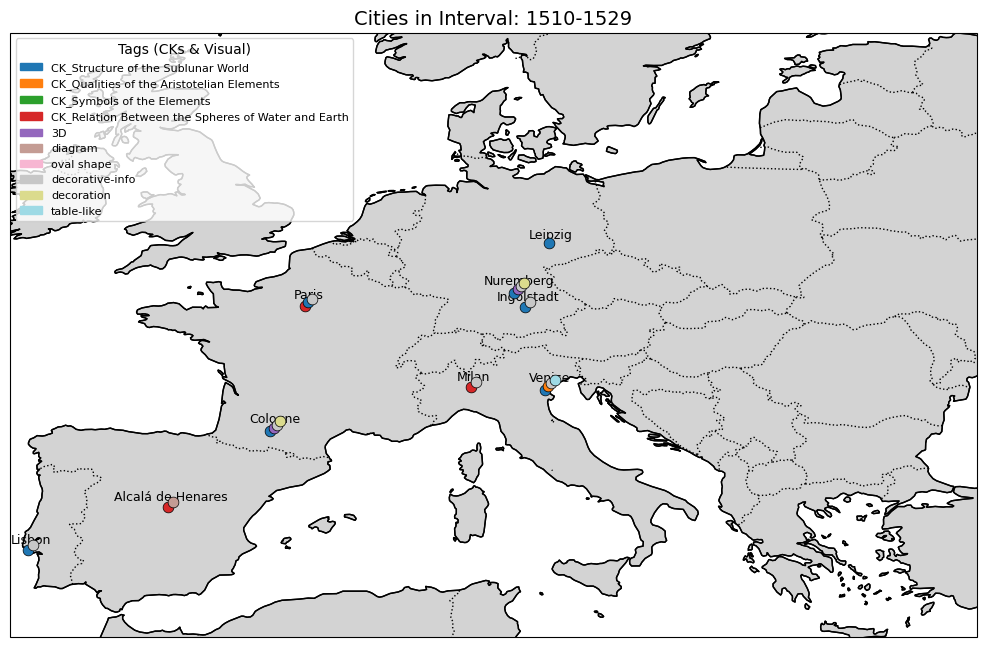

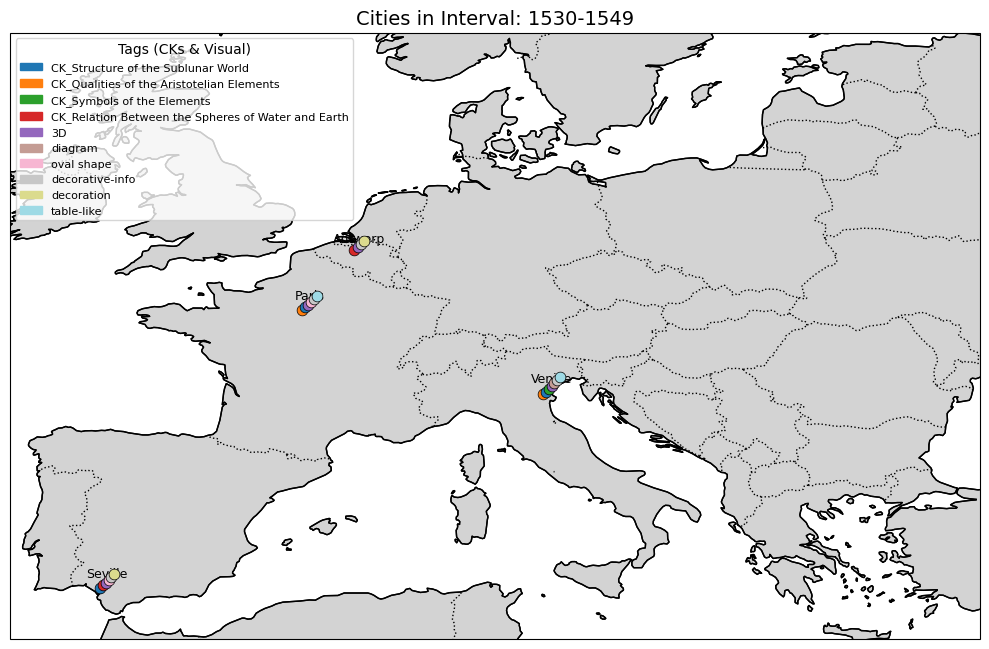

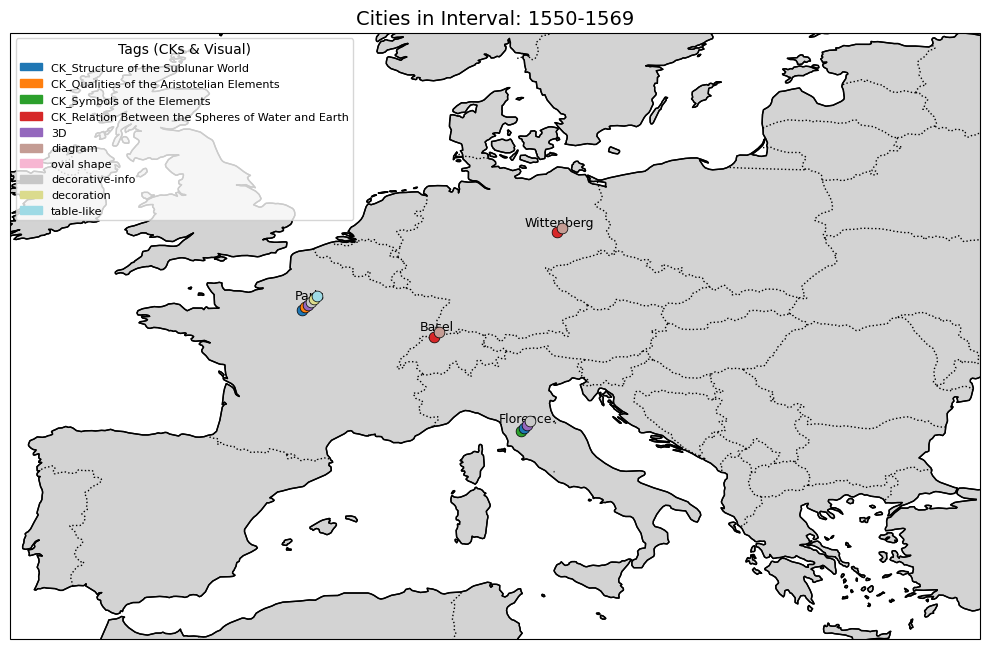

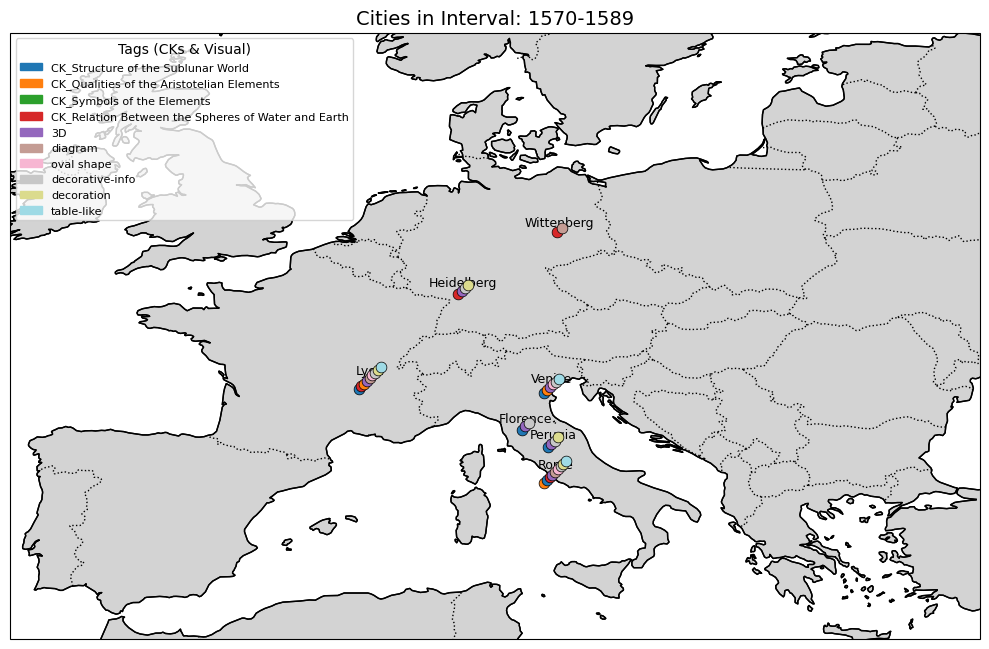

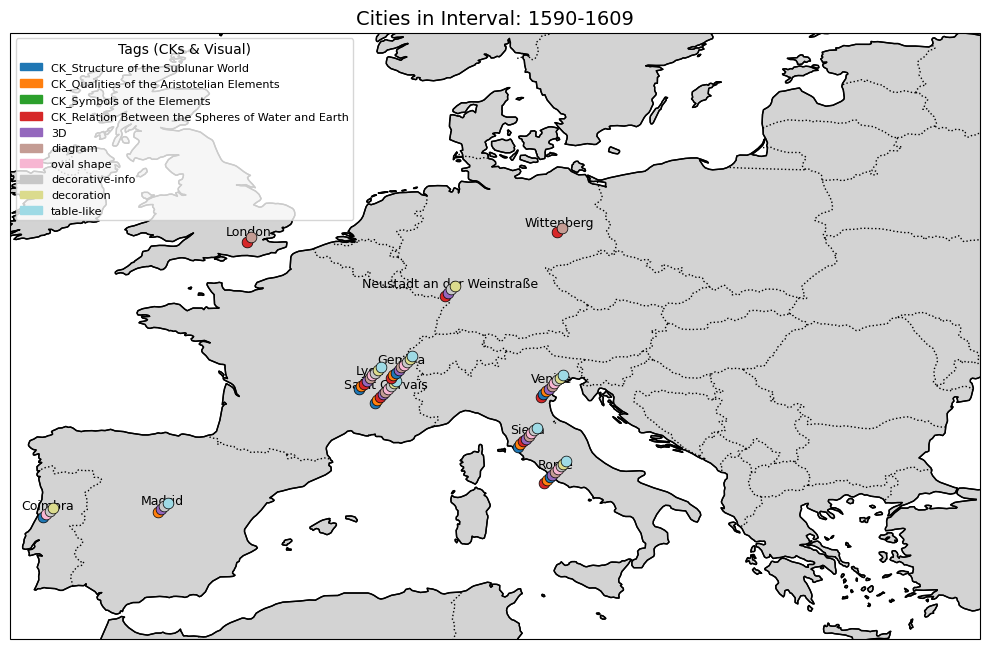

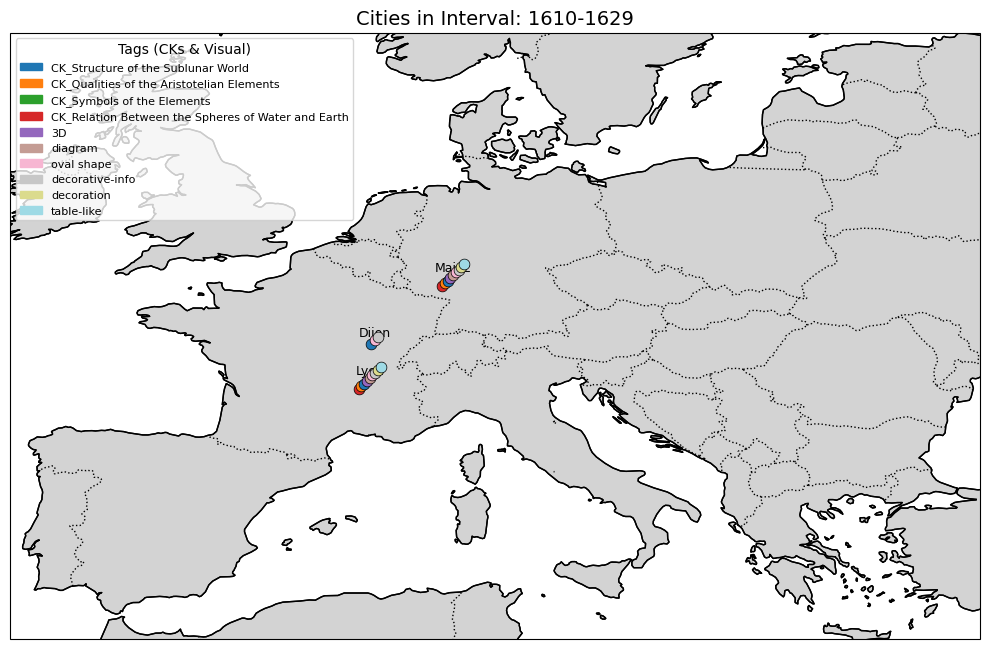

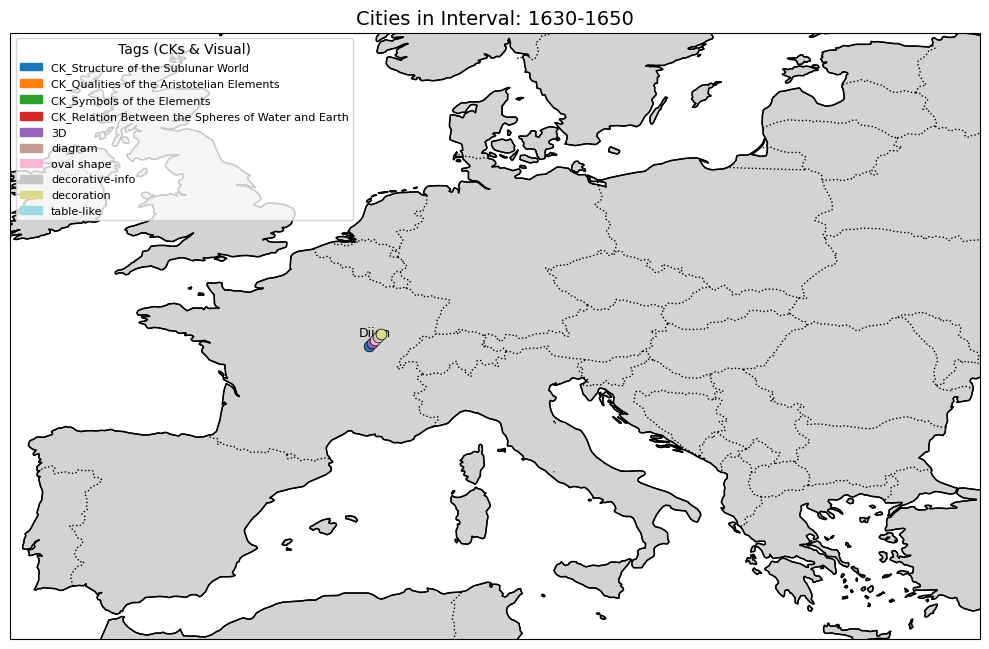

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import numpy as np

# === SETUP ===

target_cks = [
   'CK_Structure of the Sublunar World',
   'CK_Qualities of the Aristotelian Elements',
   'CK_Symbols of the Elements',
   'CK_Relation Between the Spheres of Water and Earth'
]

target_visual_tags = ['3D', 'diagram', 'oval shape', 'decorative-info', 'decoration', 'table-like']  # Columns with 'yes'/'no'

# Map extent (adjust as needed)
min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

# Get sorted intervals
sorted_intervals = sorted(visual_df['year_interval'].dropna().unique())

# Create color map for CKs + visual tags combined
all_tags = target_cks + target_visual_tags
colors = plt.cm.tab20(np.linspace(0, 1, len(all_tags)))  # Use colormap with enough distinct colors
tag_color_map = dict(zip(all_tags, colors))

# === FUNCTION TO PLOT EACH INTERVAL ===

def plot_static_map_for_interval(interval):
    fig, ax = plt.subplots(figsize=(10, 8), dpi=100, subplot_kw={'projection': ccrs.PlateCarree()})

    # Base map
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray')
    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())

    # Filter data for the interval
    df_interval = visual_df[visual_df['year_interval'] == interval]

    # Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    )

    # Drop duplicate places to plot one label per city
    gdf_unique = gdf.drop_duplicates(subset=['place'])

    # Plot points for each city, one dot per CK or visual tag present
    for _, city_row in gdf_unique.iterrows():
        city = city_row['place']
        lon, lat = city_row['longitude'], city_row['latitude']

        # Subset all records for this city and interval
        city_records = df_interval[df_interval['place'] == city]

        # Collect all CKs present
        cks_present = city_records['cks'].dropna().unique()
        cks_present = [ck for ck in cks_present if ck in target_cks]

        # Collect visual tags present ('yes' values)
        visual_present = [tag for tag in target_visual_tags if (city_records[tag] == 'yes').any()]

        # Combine all tags
        tags_present = list(cks_present) + visual_present

        # Plot each tag with a slight offset so dots don’t overlap exactly
        offset_step = 0.1
        n = len(tags_present)
        offsets = np.linspace(-offset_step * n/2, offset_step * n/2, n)

        for i, tag in enumerate(tags_present):
            ax.scatter(
                lon + offsets[i], lat + offsets[i], 
                color=tag_color_map[tag], 
                s=60, 
                transform=ccrs.PlateCarree(),
                edgecolor='k',
                linewidth=0.5,
                zorder=5
            )

        # Add city label once
        ax.text(lon, lat + 0.15, city, fontsize=9, ha='center', transform=ccrs.PlateCarree())

    # Create legend entries
    legend_handles = []
    for tag, color in tag_color_map.items():
        legend_handles.append(mpatches.Patch(color=color, label=tag))

    ax.legend(handles=legend_handles, loc='upper left', fontsize=8, title="Tags (CKs & Visual)")

    ax.set_title(f"Cities in Interval: {interval}", fontsize=14)
    plt.tight_layout()
    plt.show()

# === RUN PLOTS ===
for interval in sorted_intervals:
    plot_static_map_for_interval(interval)


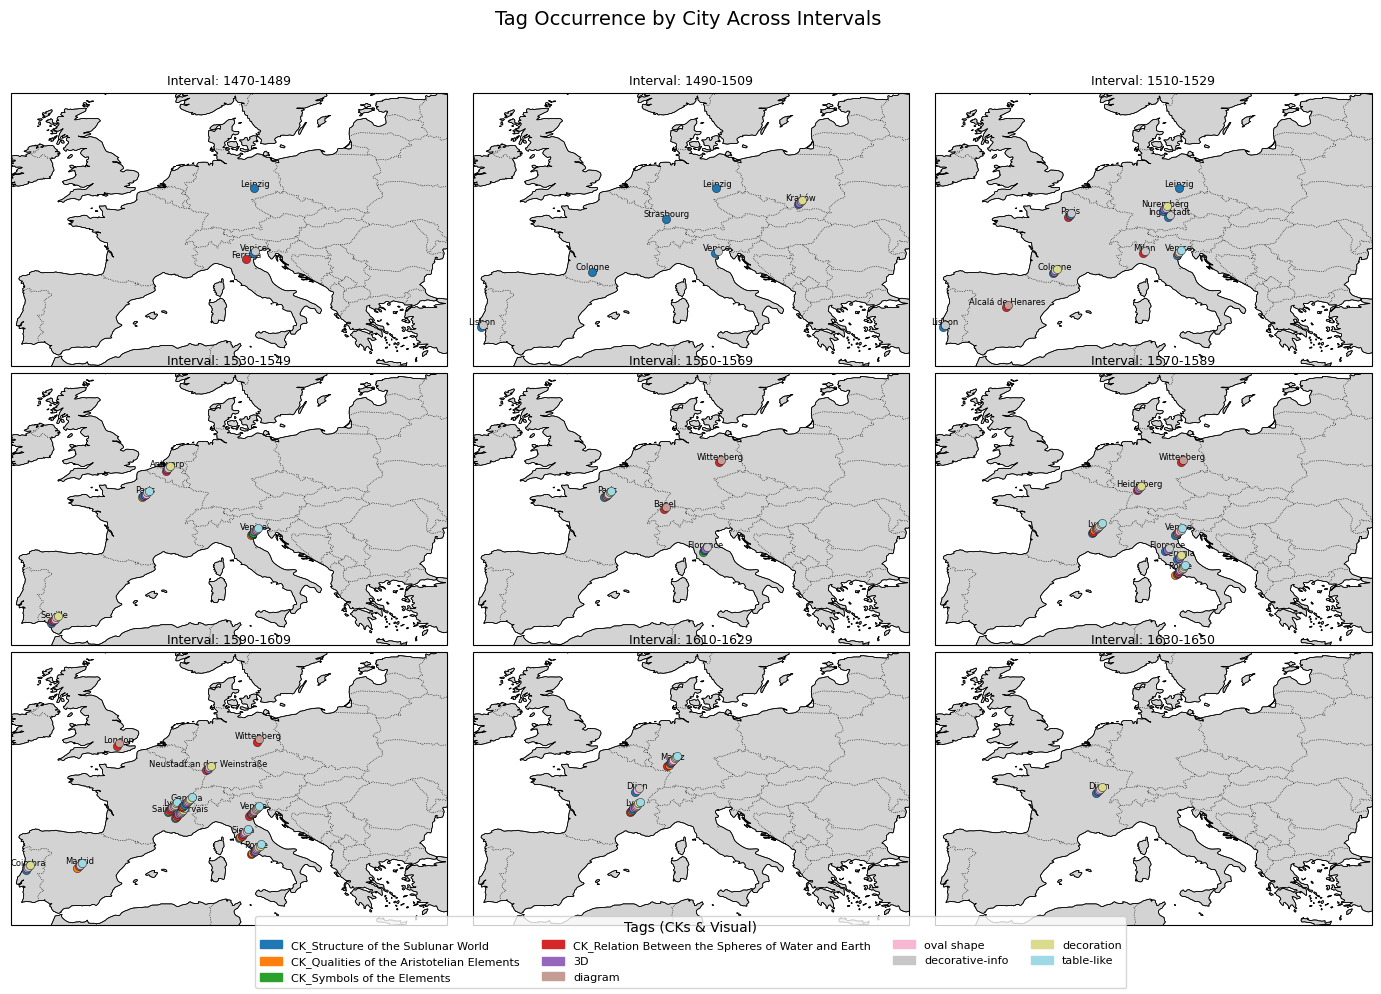

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np

# === SETUP ===

target_cks = [
    'CK_Structure of the Sublunar World',
    'CK_Qualities of the Aristotelian Elements',
    'CK_Symbols of the Elements',
    'CK_Relation Between the Spheres of Water and Earth'
]

target_visual_tags = ['3D', 'diagram', 'oval shape', 'decorative-info', 'decoration', 'table-like']

min_lon, max_lon = -10, 30
min_lat, max_lat = 35, 60

sorted_intervals = sorted(visual_df['year_interval'].dropna().unique())

# Color map
all_tags = target_cks + target_visual_tags
colors = plt.cm.tab20(np.linspace(0, 1, len(all_tags)))
tag_color_map = dict(zip(all_tags, colors))

# === FUNCTION TO DRAW A SINGLE INTERVAL ON GIVEN AX ===

def plot_interval_on_ax(ax, interval):
    df_interval = visual_df[visual_df['year_interval'] == interval]
    gdf = gpd.GeoDataFrame(
        df_interval,
        geometry=gpd.points_from_xy(df_interval['longitude'], df_interval['latitude']),
        crs="EPSG:4326"
    )
    gdf_unique = gdf.drop_duplicates(subset=['place'])

    ax.set_extent([min_lon, max_lon, min_lat, max_lat], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)

    for _, city_row in gdf_unique.iterrows():
        city = city_row['place']
        lon, lat = city_row['longitude'], city_row['latitude']
        city_records = df_interval[df_interval['place'] == city]

        cks_present = city_records['cks'].dropna().unique()
        cks_present = [ck for ck in cks_present if ck in target_cks]
        visual_present = [tag for tag in target_visual_tags if (city_records[tag] == 'yes').any()]
        tags_present = list(cks_present) + visual_present

        offset_step = 0.1
        n = len(tags_present)
        offsets = np.linspace(-offset_step * n / 2, offset_step * n / 2, n)

        for i, tag in enumerate(tags_present):
            ax.scatter(
                lon + offsets[i], lat + offsets[i],
                color=tag_color_map[tag],
                s=35,
                transform=ccrs.PlateCarree(),
                edgecolor='k', linewidth=0.3, zorder=5
            )
        ax.text(lon, lat + 0.15, city, fontsize=6, ha='center', transform=ccrs.PlateCarree())

    ax.set_title(f"Interval: {interval}", fontsize=9)

# === PLOTTING IN 3x3 GRID ===

per_page = 9
num_pages = int(np.ceil(len(sorted_intervals) / per_page))

for page in range(num_pages):
    start = page * per_page
    end = min((page + 1) * per_page, len(sorted_intervals))
    intervals_subset = sorted_intervals[start:end]

    fig, axs = plt.subplots(3, 3, figsize=(14, 10), subplot_kw={'projection': ccrs.PlateCarree()})
    axs = axs.flatten()

    for i, interval in enumerate(intervals_subset):
        plot_interval_on_ax(axs[i], interval)

    # Hide unused subplots
    for j in range(len(intervals_subset), 9):
        axs[j].set_visible(False)

    # Add common legend (only once per page)
    legend_handles = [mpatches.Patch(color=color, label=tag) for tag, color in tag_color_map.items()]
    fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=8, title='Tags (CKs & Visual)')

    plt.suptitle("Tag Occurrence by City Across Intervals", fontsize=14)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Leave space for legend and title

    plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_geotemporal.png', dpi=300)

    plt.show()


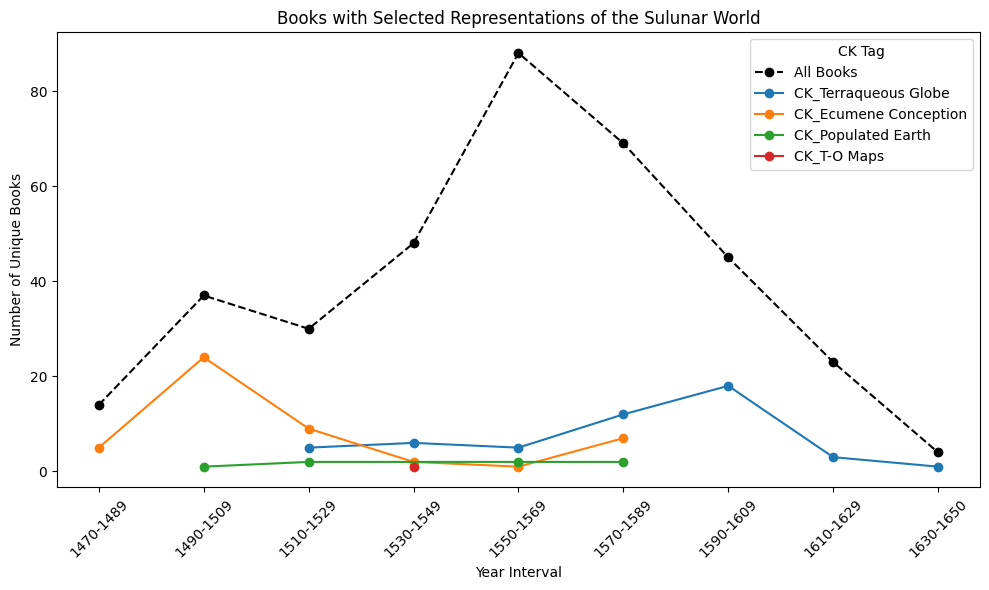

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# === PARAMETERS ===

# Define the CK values you want to follow
target_cks = [
    'CK_Terraqueous Globe',
    'CK_Ecumene Conception',
    'CK_Populated Earth',
    'CK_T-O Maps'
]

# === PREPARE DATA ===

# Count total unique books per interval (from 'books' DataFrame)
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Create a consistent list of intervals for alignment
intervals = unique_books_count.index.astype(str)

# Count unique books with each CK value per interval (from 'df' DataFrame)
book_counts = {
    keyword: (
        visual_df[visual_df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(unique_books_count.index, fill_value=0)
    )
    for keyword in target_cks
}

# === PLOTTING ===

plt.figure(figsize=(10, 6))

# Plot total books
plt.plot(intervals, unique_books_count.values, label='All Books', marker='o', color='black', linestyle='--')

# Plot each CK line (only where value > 0)
for keyword, series in book_counts.items():
    non_zero_intervals = [interval for interval, val in zip(intervals, series.values) if val > 0]
    non_zero_values = [val for val in series.values if val > 0]
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# === FORMATTING ===

plt.title('Books with Selected Representations of the Sulunar World')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='CK Tag')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_rep_earth.png', dpi=300)


plt.show()


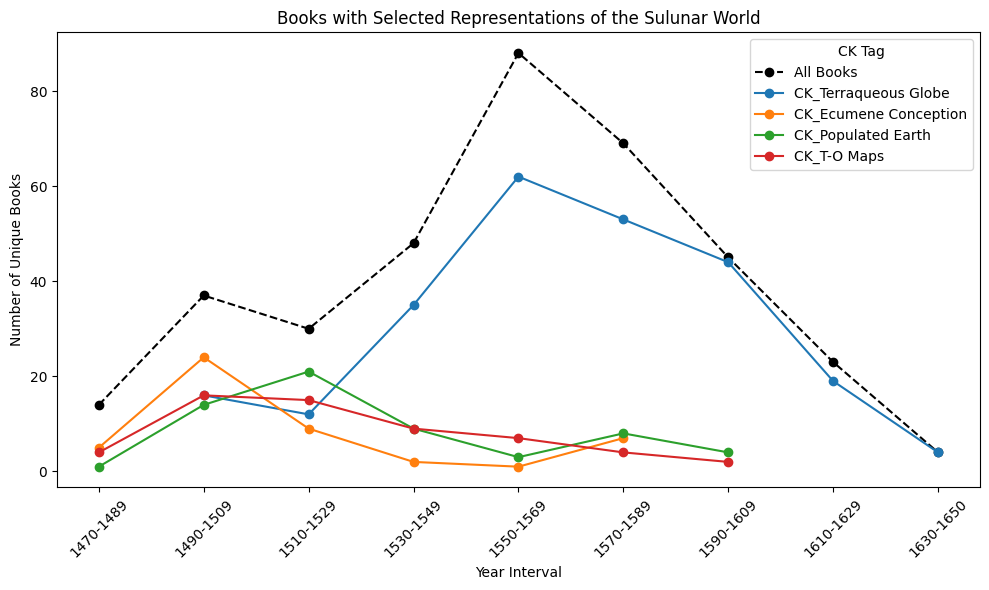

In [75]:
import pandas as pd
import matplotlib.pyplot as plt

# === PARAMETERS ===

# Define the CK values you want to follow
target_cks = [
    'CK_Terraqueous Globe',
    'CK_Ecumene Conception',
    'CK_Populated Earth',
    'CK_T-O Maps'
]

# === PREPARE DATA ===

# Count total unique books per interval (from 'books' DataFrame)
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()

# Create a consistent list of intervals for alignment
intervals = unique_books_count.index.astype(str)

# Count unique books with each CK value per interval (from 'df' DataFrame)
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .reindex(unique_books_count.index, fill_value=0)
    )
    for keyword in target_cks
}

# === PLOTTING ===

plt.figure(figsize=(10, 6))

# Plot total books
plt.plot(intervals, unique_books_count.values, label='All Books', marker='o', color='black', linestyle='--')

# Plot each CK line (only where value > 0)
for keyword, series in book_counts.items():
    non_zero_intervals = [interval for interval, val in zip(intervals, series.values) if val > 0]
    non_zero_values = [val for val in series.values if val > 0]
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

# === FORMATTING ===

plt.title('Books with Selected Representations of the Sulunar World')
plt.xlabel('Year Interval')
plt.ylabel('Number of Unique Books')
plt.xticks(rotation=45)
plt.legend(title='CK Tag')
plt.tight_layout()

plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/plots/source_analysis/1.3_rep_earth_full_corpus.png', dpi=300)


plt.show()
